for each mouse plot across sessions:
- avg speed of homings
- avg number of homings
- avg number of homings targeting each goal
- spatial efficiency!

In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_17aug, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import (
    JAL4_3rdSept,
    JAL4_19thSept,
    JAL4_11thSept,
    JAL4_28aug,
    JAL4_17aug,
)

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_2ndSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import (
    JAL6_shelt_4mar,
    JAL6_28mar,
    JAL6_flip5_25mar,
    JAL6_flip7_1apr,
    JAL6_flip4_21mar,
    JAL6_flip3_18mar,
)

from behave_analysis.database.Experiments.JAL007_ex import (
    JAL7_empty_shelter_5mar,
    JAL7_sesh8_9apr,
    JAL7_sesh9_16apr,
    JAL7_flip2_12mar,
    JAL7_flip5_22mar,
    JAL7_23apr,
    JAL7_30apr,
)

from behave_analysis.database.Experiments.JAL008_ex import (
    JAL8_shelt_22apr,
    JAL8_flip1_25apr,
    JAL8_flip2_29apr,
    JAL8_tiny_3may,
    JAL8_flip4_10may,
    JAL8_14may,
    JAL8_21may,
    JAL8_flip3_7may,
)

experiments_objects = [JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
                        JAL4_3rdSept,JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
                        JAL005_8thSept, JAL005_21stSept,
                        JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, JAL6_flip7_1apr,
                        JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
                        JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip4_10may, JAL8_14may,
                        JAL8_tiny_3may, JAL8_21may, JAL7_30apr,
                        JAL005_2ndSept,JAL4_17aug, JAL3_17aug, JAL8_shelt_22apr, JAL7_empty_shelter_5mar, JAL6_shelt_4mar, JAL005_5thSept]

sesh_by_mouse = {'JAL003': ['2023_08_17','2023_08_22','2023_08_25','2023_08_29','2023_09_01','2023_09_04','2023_09_07'],
                'JAL004': ['2023_08_17','2023_08_21','2023_08_24','2023_08_28','2023_09_03','2023_09_11','2023_09_19'],
                'JAL005': ['2023_09_02','2023_09_05','2023_09_08','2023_09_14','2023_09_21','2023_09_26','2023_09_28'],
                'JAL006': ['2024_03_04','2024_03_11','2024_03_14','2024_03_18','2024_03_21','2024_03_25','2024_03_28','2024_04_01','2024_04_05'],
                'JAL007': ['2024_03_05','2024_03_12','2024_03_15','2024_03_19','2024_03_22','2024_03_26','2024_04_04','2024_04_09','2024_04_16','2024_04_23'],
                'JAL008': ['2024_04_22','2024_04_25','2024_04_29','2024_05_7','2024_05_10','2024_05_14']}

In [2]:
import os 
import dill as pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline

from behave_analysis.process.session import get_experiment 
from behave_analysis.process.process import Process
from behave_analysis.analyze.behaviour.plot_homings import hist_initial_heading_angle

In [22]:
"""Load homings"""
all_sesh = {}
for s,sesh in enumerate(experiments_objects):
    # load session deets
    session = get_experiment(sesh)
    homie_path = os.path.join(session.base_path,session.processed_path,'homings',r"homings_obj.pkl")
    with open(homie_path, "rb") as dill_file:
        homie = pickle.load(dill_file)
    cond = [x for x in homie.homing_condition]
    homie_by_cond = {} # keep
    for i,c in enumerate(list(set(cond))):
        homie_by_cond[c] = np.sum([1 for x in cond if x == c])
    track_path = os.path.join(session.base_path,session.processed_path,r"fully_processed_tracking_data.pickle")
    with open(track_path, "rb") as dill_file:
        tracking_data = pickle.load(dill_file)
    heading_by_cond = hist_initial_heading_angle(
            session=session,
            onsets=homie.onset_frames,
            offsets=homie.offset_frames,
            head_angle=homie.homing_angles_dic["avg_hdir"],
            all_conditions=homie.homing_condition,
            tracking_data=tracking_data,
            title="homing",
            plotting = False,
        )
    
    exp = {'speed': homie.avg_speed,
           'num_homings': len(homie.onset_frames),
           'homie_by_cond': homie_by_cond,
           'heading_by_cond': heading_by_cond,
           'spatial_efficiency': homie.spatial_efficiency}

    if not session.mouse in all_sesh.keys():
        all_sesh[session.mouse] = {}
    all_sesh[session.mouse][sesh.experiment_date] = exp


c:\Users\Jasmine\AppData\Local\miniconda3\envs\JALpipeline\lib\site-packages\numpy\linalg\linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


Text(0, 0.5, 'avg homing speed cm/s')

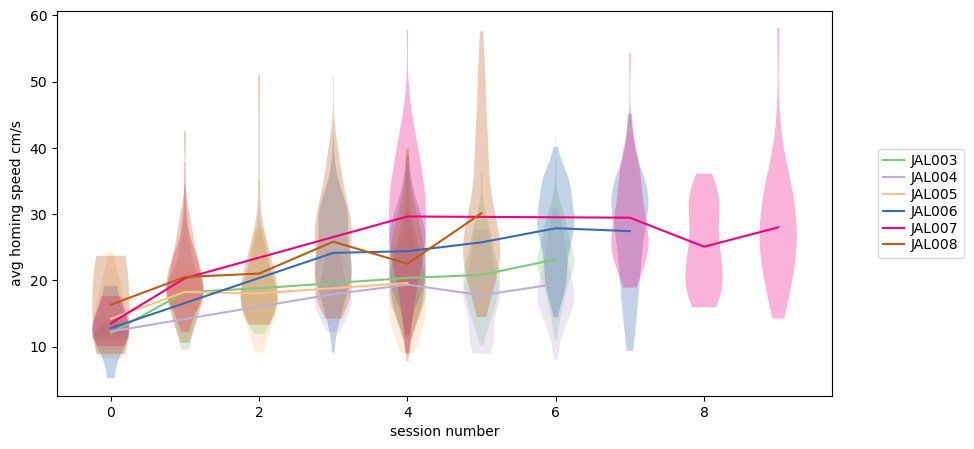

In [9]:
"""Look at homing speed across sessions"""
_, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

colormap = cm.get_cmap('Accent')
num_colors = len(all_sesh.keys())
colors = [colormap(i / num_colors) for i in range(num_colors)]

for m_idx, m in enumerate(all_sesh.keys()):
    sessions = np.arange(len(sesh_by_mouse[m]))
    speed = np.zeros(len(sesh_by_mouse[m]))
    for sesh_idx, date in enumerate(sesh_by_mouse[m]):
        if date in all_sesh[m].keys():
            violin = ax.violinplot(all_sesh[m][date]['speed'], positions = [sesh_idx], showextrema = False)
            for pc in violin['bodies']:
                pc.set_facecolor(colors[m_idx])
            speed[sesh_idx] = np.nanmean(all_sesh[m][date]['speed'])
    mask = speed != 0
    ax.plot(sessions[mask],speed[mask], color = colors[m_idx])
ax.legend(all_sesh.keys(),
            loc='center left', 
            bbox_to_anchor=(1.05, .5),
            columnspacing=1.0, labelspacing=0.2,
            handletextpad=0.5, handlelength=1.5)
ax.set_xlabel('session number')
ax.set_ylabel('avg homing speed cm/s')

Text(0, 0.5, 'number of homings per session')

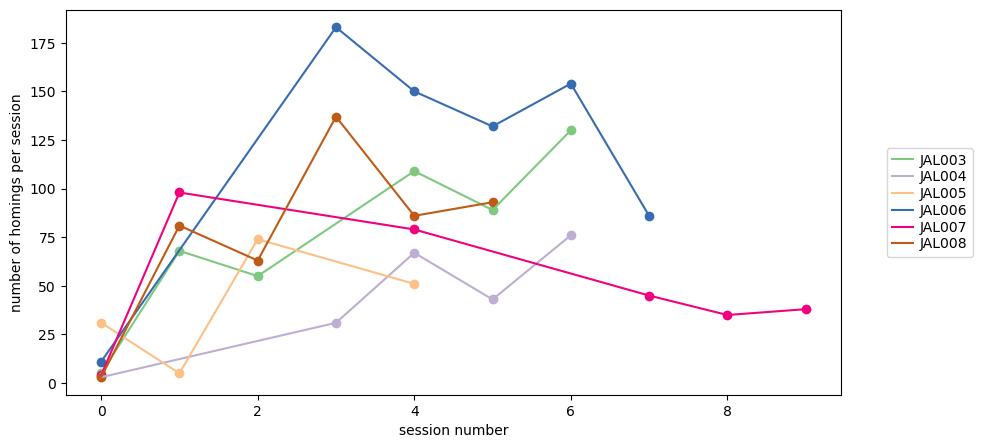

In [8]:
"""Look at number of homings across sessions"""
_, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

colormap = cm.get_cmap('Accent')
num_colors = len(all_sesh.keys())
colors = [colormap(i / num_colors) for i in range(num_colors)]

for m_idx, m in enumerate(all_sesh.keys()):
    sessions = np.arange(len(sesh_by_mouse[m]))
    homie_num = np.zeros(len(sesh_by_mouse[m]))
    for sesh_idx, date in enumerate(sesh_by_mouse[m]):
        if date in all_sesh[m].keys():
            homie_num[sesh_idx] = all_sesh[m][date]['num_homings']
    mask = homie_num != 0
    ax.plot(sessions[mask],homie_num[mask], color = colors[m_idx])
    ax.scatter(sessions[mask],homie_num[mask], color = colors[m_idx])
ax.legend(all_sesh.keys(),
            loc='center left', 
            bbox_to_anchor=(1.05, .5),
            columnspacing=1.0, labelspacing=0.2,
            handletextpad=0.5, handlelength=1.5)
ax.set_xlabel('session number')
ax.set_ylabel('number of homings per session')

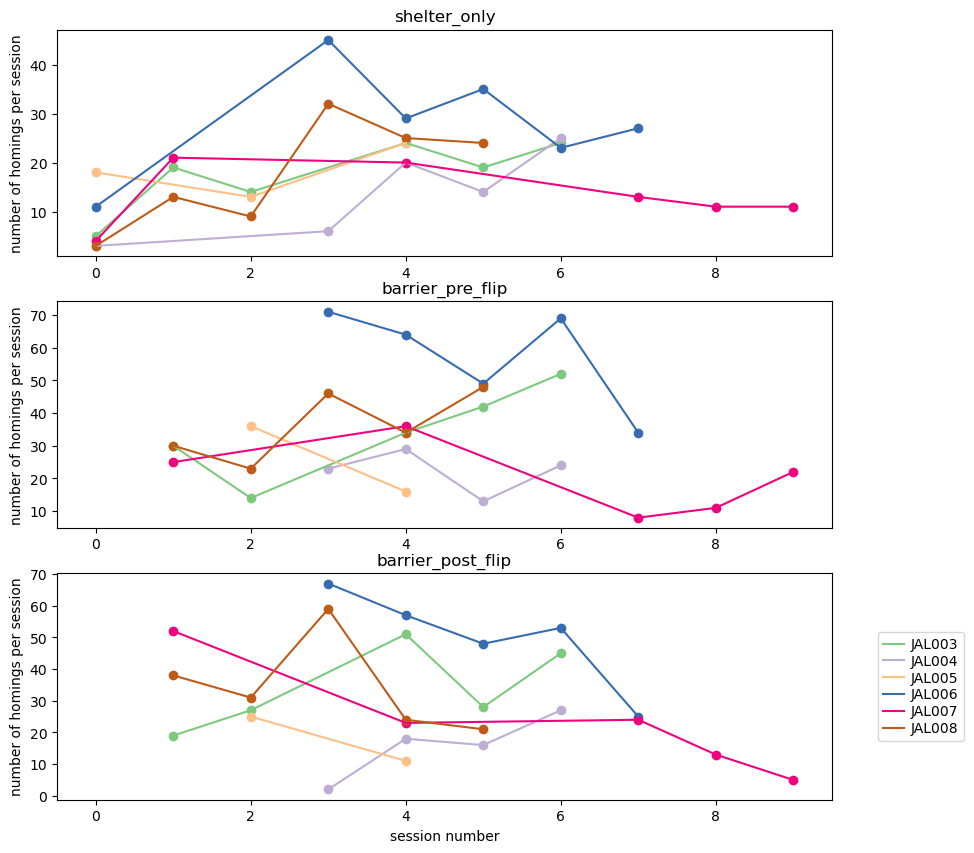

In [32]:
"""Look at number of homings per condition across sessions"""
_, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 10))

colormap = cm.get_cmap('Accent')
num_colors = len(all_sesh.keys())
colors = [colormap(i / num_colors) for i in range(num_colors)]

for m_idx, m in enumerate(all_sesh.keys()):
    sessions = np.arange(len(sesh_by_mouse[m]))
    homie_shelt = np.zeros(len(sesh_by_mouse[m]))
    homie_pre = np.zeros(len(sesh_by_mouse[m]))
    homie_post = np.zeros(len(sesh_by_mouse[m]))
    for sesh_idx, date in enumerate(sesh_by_mouse[m]):
        if date in all_sesh[m].keys():
            if 'shelter_only' in all_sesh[m][date]['homie_by_cond']:
                homie_shelt[sesh_idx] = all_sesh[m][date]['homie_by_cond']['shelter_only']
            if 'shelter_present' in all_sesh[m][date]['homie_by_cond']:
                homie_shelt[sesh_idx] = all_sesh[m][date]['homie_by_cond']['shelter_present']
            if 'barrier_pre_flip' in all_sesh[m][date]['homie_by_cond']:
                homie_pre[sesh_idx] = all_sesh[m][date]['homie_by_cond']['barrier_pre_flip']
            if 'barrier_post_flip' in all_sesh[m][date]['homie_by_cond']:
                homie_post[sesh_idx] = all_sesh[m][date]['homie_by_cond']['barrier_post_flip']
    mask = homie_shelt != 0
    ax[0].plot(sessions[mask],homie_shelt[mask], color = colors[m_idx])
    ax[0].scatter(sessions[mask],homie_shelt[mask], color = colors[m_idx])
    mask = homie_pre != 0
    ax[1].plot(sessions[mask],homie_pre[mask], color = colors[m_idx])
    ax[1].scatter(sessions[mask],homie_pre[mask], color = colors[m_idx])
    mask = homie_post != 0
    ax[2].plot(sessions[mask],homie_post[mask], color = colors[m_idx])
    ax[2].scatter(sessions[mask],homie_post[mask], color = colors[m_idx])
ax[2].legend(all_sesh.keys(),
            loc='center left', 
            bbox_to_anchor=(1.05, .5),
            columnspacing=1.0, labelspacing=0.2,
            handletextpad=0.5, handlelength=1.5)
ax[2].set_xlabel('session number')
title = ['shelter_only','barrier_pre_flip','barrier_post_flip']
for i in np.arange(3):
    ax[i].set_xlim([-.5,9.5])
    ax[i].set_ylabel('number of homings per session')
    ax[i].set_title(title[i])

Text(0, 0.5, 'avg homing spatial effciency')

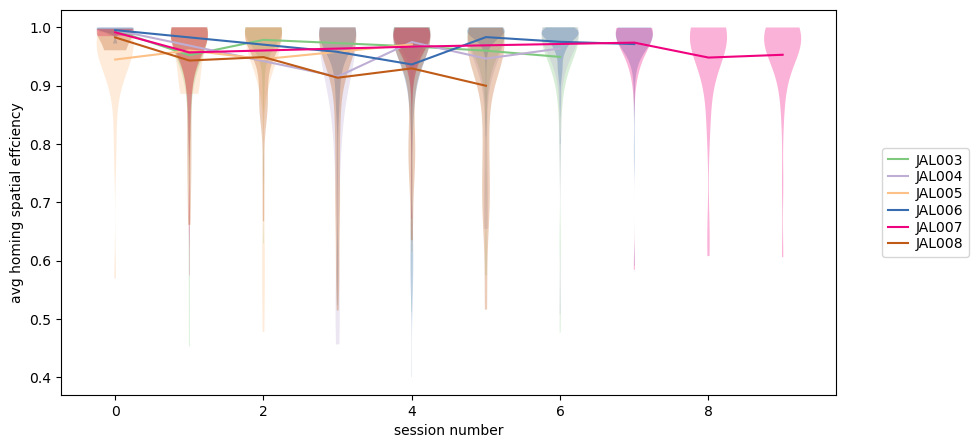

In [11]:
"""Look at homing spatial efficiency across sessions"""
_, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 5))

colormap = cm.get_cmap('Accent')
num_colors = len(all_sesh.keys())
colors = [colormap(i / num_colors) for i in range(num_colors)]

for m_idx, m in enumerate(all_sesh.keys()):
    sessions = np.arange(len(sesh_by_mouse[m]))
    speed = np.zeros(len(sesh_by_mouse[m]))
    for sesh_idx, date in enumerate(sesh_by_mouse[m]):
        if date in all_sesh[m].keys():
            violin = ax.violinplot(all_sesh[m][date]['spatial_efficiency'], positions = [sesh_idx], showextrema = False)
            for pc in violin['bodies']:
                pc.set_facecolor(colors[m_idx])
            speed[sesh_idx] = np.mean(all_sesh[m][date]['spatial_efficiency'])
    mask = speed != 0
    ax.plot(sessions[mask],speed[mask], color = colors[m_idx])
ax.legend(all_sesh.keys(),
            loc='center left', 
            bbox_to_anchor=(1.05, .5),
            columnspacing=1.0, labelspacing=0.2,
            handletextpad=0.5, handlelength=1.5)
ax.set_xlabel('session number')
ax.set_ylabel('avg homing spatial effciency')

In [33]:
all_sesh['JAL005']['2023_09_02']['heading_by_cond']

{'all_time': array([ 8., 17.,  6.]),
 'shelter_present': array([0., 0., 0.]),
 'pre_shelter': array([0., 0., 0.])}

In [ ]:
"""Look at number of homings per condition across sessions"""
_, ax = plt.subplots(nrows=3, ncols=1, figsize=(10, 10))

colormap = cm.get_cmap('Accent')
num_colors = len(all_sesh.keys())
colors = [colormap(i / num_colors) for i in range(num_colors)]

for m_idx, m in enumerate(all_sesh.keys()):
    sessions = np.arange(len(sesh_by_mouse[m]))
    homie_shelt = np.zeros(len(sesh_by_mouse[m]))
    homie_pre = np.zeros(len(sesh_by_mouse[m]))
    homie_post = np.zeros(len(sesh_by_mouse[m]))
    for sesh_idx, date in enumerate(sesh_by_mouse[m]):
        if date in all_sesh[m].keys():
            if 'shelter_only' in all_sesh[m][date]['homie_by_cond']:
                homie_shelt[sesh_idx] = all_sesh[m][date]['homie_by_cond']['shelter_only']
            if 'shelter_present' in all_sesh[m][date]['homie_by_cond']:
                homie_shelt[sesh_idx] = all_sesh[m][date]['homie_by_cond']['shelter_present']
            if 'barrier_pre_flip' in all_sesh[m][date]['homie_by_cond']:
                homie_pre[sesh_idx] = all_sesh[m][date]['homie_by_cond']['barrier_pre_flip']
            if 'barrier_post_flip' in all_sesh[m][date]['homie_by_cond']:
                homie_post[sesh_idx] = all_sesh[m][date]['homie_by_cond']['barrier_post_flip']